In [4]:
import pandas as pd 
import numpy as np 


#verificacao de quantidade e percentual das classes (III)

df_financas = pd.read_csv("financas_data.csv")

contagem = (df_financas["loan_status"].value_counts())
percentual = (df_financas["loan_status"].value_counts(normalize=True) * 100) 

resumo = pd.DataFrame({
    "quantidade": contagem,
    "percentual": percentual.round(2)
    
})
display(resumo)
df_financas.shape


,quantidade,percentual
loan_status,,
0,35000,77.78
1,10000,22.22


(45000, 14)

In [5]:
#separacao da base para teste e desenvolvimento (IV)

from sklearn.model_selection import train_test_split

x = df_financas.drop(columns=["loan_status"]) #colunas que o programa vai usar para prever menos a target (.drop())
y = df_financas["loan_status"] #coluna alvo isolada

x_dev, x_test, y_dev, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state=42)

#separacao para pré processsamento 

colunas_numericas = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

colunas_categoricas = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]
len(colunas_numericas), len(colunas_categoricas)


#COMENTARIOS 

#SKLEARN - biblioteca
#MODEL_SELECTION - ferramenta do sklearn para separar e avaliar dados
#TRAIN_TEST_SPLIT - dividir/separar os dados

(8, 5)

In [6]:
#pre-processamento e representacao TF-IDF para textos e One-Hot Encoding para variáveis categóricas (V)
#aqui utilizaremos One-Hot pois temos apenas variaveis categoricas e nao de texto 

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler #coloca variaveis numericas em escala comparaveis
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessador = ColumnTransformer(#objeto
    transformers=[
        ("numericas", StandardScaler(), colunas_numericas),
        ("categoricas", encoder, colunas_categoricas) #aplicar o encoder na colunas_categoricas
        
    ],
    remainder="passthrough" #nao passe pelas colunas que nao foram mencionadas
)

x_dev_preparado = preprocessador.fit_transform(x_dev) #fit_transform == aprenda as categorias e transforme em dados 
x_test_preparado = preprocessador.transform(x_test)

x_dev_preparado.shape
x_test_preparado.shape
preprocessador.get_feature_names_out()

array(['numericas__person_age', 'numericas__person_income',
       'numericas__person_emp_exp', 'numericas__loan_amnt',
       'numericas__loan_int_rate', 'numericas__loan_percent_income',
       'numericas__cb_person_cred_hist_length', 'numericas__credit_score',
       'categoricas__person_gender_female',
       'categoricas__person_gender_male',
       'categoricas__person_education_Associate',
       'categoricas__person_education_Bachelor',
       'categoricas__person_education_Doctorate',
       'categoricas__person_education_High School',
       'categoricas__person_education_Master',
       'categoricas__person_home_ownership_MORTGAGE',
       'categoricas__person_home_ownership_OTHER',
       'categoricas__person_home_ownership_OWN',
       'categoricas__person_home_ownership_RENT',
       'categoricas__loan_intent_DEBTCONSOLIDATION',
       'categoricas__loan_intent_EDUCATION',
       'categoricas__loan_intent_HOMEIMPROVEMENT',
       'categoricas__loan_intent_MEDICAL',
      

In [7]:
#montando pipeline e fazendo a validacao cruzada

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold #StratifiedKFold - fazer validacao cruzada

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo 1: Regressão Logística
pipeline_logreg = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])
parametros_logreg = {"modelo__C": [0.01, 0.1, 1, 10]}

# Modelo 2: Random Forest
pipeline_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(random_state=42, n_jobs=1))
])
parametros_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [5, 10, None]
}

# Modelo 3: Gradient Boosting
pipeline_gb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", GradientBoostingClassifier(random_state=42))
])
parametros_gb = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__max_depth": [2, 3]
}

print(pipeline_logreg)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numericas', StandardScaler(),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['person_gender',
                                                   'person_education',
                     

In [8]:
#Regressao Logostica (VI) relatorio
busca_logreg = RandomizedSearchCV(
    estimator=pipeline_logreg,
    param_distributions=parametros_logreg,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=4,
    random_state=42,
    n_jobs=-1
)

busca_logreg.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_logreg.best_params_)

print("\nMelhor Average precision na validação (RL):")
print(busca_logreg.best_score_)

#Random Forest
busca_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_rf,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=6,
    random_state=42,
    n_jobs=-1
)

busca_rf.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_rf.best_params_)

print("\nMelhor Average Precision na validação:")
print(busca_rf.best_score_)

#Grandient Boosting
busca_gb = RandomizedSearchCV(
    estimator=pipeline_gb,
    param_distributions=parametros_gb,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=8,
    random_state=42,
    n_jobs=-1
)

busca_gb.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_gb.best_params_)

print("\nMelhor Average Precision na validação (GB):")
print(busca_gb.best_score_)

Melhores parâmetros:
{'modelo__C': 0.1}

Melhor Average precision na validação (RL):
0.8540050935289993
Melhores parâmetros:
{'modelo__n_estimators': 200, 'modelo__max_depth': None}

Melhor Average Precision na validação:
0.9255244862777342
Melhores parâmetros:
{'modelo__n_estimators': 200, 'modelo__max_depth': 3, 'modelo__learning_rate': 0.1}

Melhor Average Precision na validação (GB):
0.9299074730337129


In [9]:
#(II) e (III)programa  / rotulos reais e probabilidades estimadas
# Melhores modelos encontrados na validação
modelo_logreg = busca_logreg.best_estimator_
modelo_rf = busca_rf.best_estimator_
modelo_gb = busca_gb.best_estimator_

# Probabilidade estimada da classe positiva (1) para cada instância do teste
prob_classe1_logreg = modelo_logreg.predict_proba(x_test)[:, 1]
prob_classe1_rf = modelo_rf.predict_proba(x_test)[:, 1]
prob_classe1_gb = modelo_gb.predict_proba(x_test)[:, 1]


resultados_prob = pd.DataFrame({
    "Rótulo real": y_test.values,
    "Prob. Logística": prob_classe1_logreg * 100,
    "Prob. Random Forest": prob_classe1_rf * 100,
    "Prob. Gradient Boosting": prob_classe1_gb * 100
})

print(resultados_prob.head(10).round(2))
y_real = y_test
print(y_real[:10])

   Rótulo real  Prob. Logística  Prob. Random Forest  Prob. Gradient Boosting
0            0             2.68                  1.5                     2.16
1            0             0.02                  0.0                     0.02
2            0             0.00                  0.0                     0.01
3            0             0.02                  0.0                     0.07
4            1            46.19                 90.5                    85.74
5            1            59.39                 45.0                    63.15
6            0             6.07                  9.5                     6.23
7            0             0.01                  0.0                     0.03
8            0            10.69                 26.5                    14.28
9            0            28.89                 35.0                    24.51
10750    0
17512    0
17070    0
35943    0
15749    1
20532    1
9857     0
17444    0
18042    0
11045    0
Name: loan_status, dtype: int64


In [10]:
# essa celula serve para calcularmos o melhor limiar para cada modelo, baseado no F1 score (que equilibra precisão e recall)

import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

#converter probabilidades para LOGIT 

def para_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

melhores = {
    "Regressão Logística": modelo_logreg,
    "Random Forest":       modelo_rf,
    "Gradient Boosting":   modelo_gb,
}

limiares = {}
for nome, modelo in melhores.items():
    # probabilidades "de mentirinha": o modelo prevê dados que não viu (validação cruzada)
    p_val = cross_val_predict(modelo, x_dev, y_dev,
                              cv=validacao_cruzada, method="predict_proba")[:, 1]
    s_val = para_logit(p_val) #converte para logit

    prec, rec, lim = precision_recall_curve(y_dev, s_val)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12) #calcula o F1 para cada limiar (f1 equilibra precisao e recall)
    limiares[nome] = lim[np.argmax(f1)] # escolhe o limiar com maior f1

    prob_equiv = 1 / (1 + np.exp(-limiares[nome])) #converte o limiar de volta para probabilidade 
    print(f"{nome}: limiar = {limiares[nome]:.4f}  (equivale a {prob_equiv*100:.1f}% de probabilidade) | F1 = {f1.max():.4f}") #mostra o F1 de cada limiar e a probabilidade equivalente

    LIMIAR = limiares[nome]


Regressão Logística: limiar = -0.3457  (equivale a 41.4% de probabilidade) | F1 = 0.7668
Random Forest: limiar = -0.2615  (equivale a 43.5% de probabilidade) | F1 = 0.8305
Gradient Boosting: limiar = -0.2261  (equivale a 44.4% de probabilidade) | F1 = 0.8333


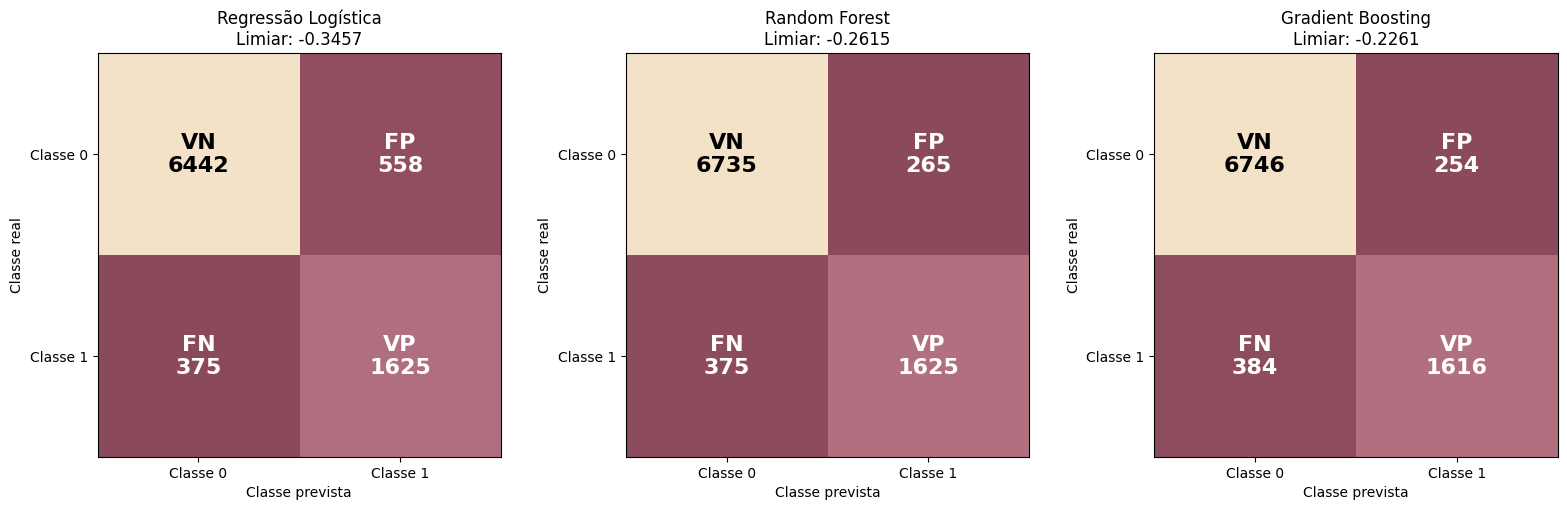

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

rosa_bege = LinearSegmentedColormap.from_list(
    "rosa_bege", ["#8b4a5c", "#e8a5b5", "#f3e2c7"]
)

siglas = np.array([
    ["VN", "FP"],
    ["FN", "VP"]
])

# Scores dos modelos no conjunto de teste
scores = {
    "Regressão Logística": para_logit(prob_classe1_logreg),
    "Random Forest": para_logit(prob_classe1_rf),
    "Gradient Boosting": para_logit(prob_classe1_gb)
}

y_true = np.array(y_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nome, s) in zip(axes, scores.items()):

    # Usa o limiar específico de cada modelo
    LIMIAR = limiares[nome]

    # Previsões usando o limiar escolhido
    y_pred = (s >= LIMIAR).astype(int)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    ax.imshow(cm, cmap=rosa_bege)

    # Valores dentro da matriz
    for i in range(2):
        for j in range(2):

            cor = "white" if cm[i, j] < cm.max() * 0.3 else "black"

            ax.text(
                j, i,
                f"{siglas[i, j]}\n{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=cor
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Classe 0", "Classe 1"])
    ax.set_yticklabels(["Classe 0", "Classe 1"])

    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")

    ax.set_title(
        f"{nome}\nLimiar: {LIMIAR:.4f}"
    )

plt.tight_layout()
plt.show()

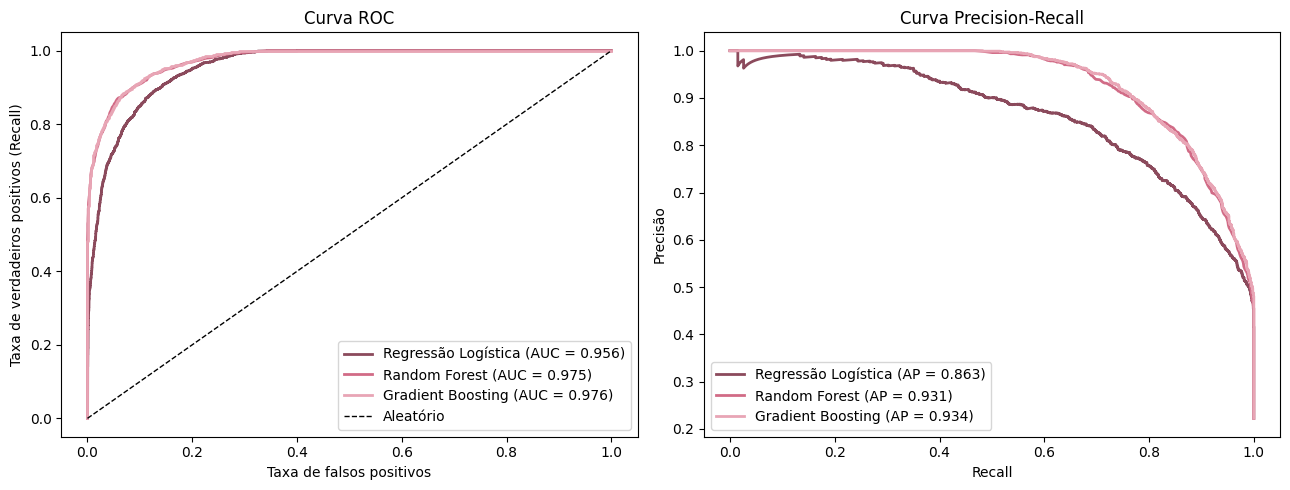

In [12]:
# Curvas ROC e Precision-Recall (VIII) - relatório

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Cores em tons de rosa
cores = {
    "Regressão Logística": "#8b4a5c",
    "Random Forest": "#d16b86",
    "Gradient Boosting": "#e8a5b5"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# =========================
# CURVA ROC
# =========================

for nome, s in scores.items():

    fpr, tpr, _ = roc_curve(y_test, s)
    auc_roc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        color=cores[nome],
        linewidth=2,
        label=f"{nome} (AUC = {auc_roc:.3f})"
    )

# Classificador aleatório
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1,
    label="Aleatório"
)

axes[0].set_xlabel("Taxa de falsos positivos")
axes[0].set_ylabel("Taxa de verdadeiros positivos (Recall)")
axes[0].set_title("Curva ROC")
axes[0].legend()


# =========================
# CURVA PRECISION-RECALL
# =========================

for nome, s in scores.items():

    precisao, recall, _ = precision_recall_curve(y_test, s)

    ap = average_precision_score(y_test, s)

    axes[1].plot(
        recall,
        precisao,
        color=cores[nome],
        linewidth=2,
        label=f"{nome} (AP = {ap:.3f})"
    )

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()


plt.tight_layout()
plt.show()

In [13]:
# histograma das probabilidades (IV) - programa'
# ============================================================
# TABELA COMPARATIVA E TEXTO AUTOMÁTICO - RELATÓRIO
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Cálculo das métricas
# ------------------------------------------------------------

resultados = []

for nome, s in scores.items():

    # Limiar específico de cada modelo
    limiar = limiares[nome]

    # Classificação utilizando o limiar escolhido
    y_pred = (s >= limiar).astype(int)

    # Curva Precision-Recall
    precisao_pr, recall_pr, _ = precision_recall_curve(y_test, s)

    # AUC-PR por integração trapezoidal
    auc_pr = auc(recall_pr, precisao_pr)

    # AP - Average Precision
    ap = average_precision_score(y_test, s)

    # Adiciona os resultados
    resultados.append({
        "Modelo": nome,
        "Limiar (logit)": limiar,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "AUC-ROC": roc_auc_score(y_test, s),
        "AUC-PR": auc_pr,
        "AP": ap
    })

tabela_resultados = pd.DataFrame(resultados)


# ------------------------------------------------------------
# 3. Formatação dos números
# ------------------------------------------------------------

tabela_formatada = tabela_resultados.style.format({
    "Limiar (logit)": "{:.4f}",
    "Acurácia": "{:.4f}",
    "Precisão": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "AUC-ROC": "{:.4f}",
    "AUC-PR": "{:.4f}",
    "AP": "{:.4f}"
})


tabela_formatada = (
    tabela_formatada
    .set_caption("Comparação dos modelos de classificação")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#8b4a5c"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#8b4a5c"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #d9a0ad")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid #e8c5cc"),
                ("padding", "8px")
            ]
        }
    ])
    .set_properties(**{
        "background-color": "#f9e8ec",
        "color": "#4a2630"
    })
)


# ------------------------------------------------------------
# 5. Destacar o maior valor de cada métrica
# ------------------------------------------------------------

colunas_metricas = [
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-score",
    "AUC-ROC",
    "AUC-PR",
    "AP"
]

tabela_formatada = tabela_formatada.highlight_max(
    subset=colunas_metricas,
    color="#e8a5b5"
)

display(tabela_formatada)


# ============================================================
# 6. TEXTO AUTOMÁTICO PARA CADA MODELO
# ============================================================

print("\n")
print("=" * 70)
print("DESCRIÇÃO DOS RESULTADOS")
print("=" * 70)

for _, resultado in tabela_resultados.iterrows():

    print(f"\n{resultado['Modelo']}")
    print("-" * 70)

    print(
        f"O modelo apresentou acurácia de "
        f"{resultado['Acurácia']:.4f}, "
        f"precisão de {resultado['Precisão']:.4f}, "
        f"recall de {resultado['Recall']:.4f} "
        f"e F1-score de {resultado['F1-score']:.4f}. "
        
        f"Para as métricas que dependem de uma decisão de "
        f"classificação, foi utilizado o limiar de "
        f"{resultado['Limiar (logit)']:.4f} em escala logit. "
        
        f"Considerando diferentes pontos de corte, o modelo "
        f"apresentou AUC-ROC de {resultado['AUC-ROC']:.4f}, "
        f"AUC-PR de {resultado['AUC-PR']:.4f} "
        f"e Average Precision (AP) de {resultado['AP']:.4f}."
    )

,Modelo,Limiar (logit),Acurácia,Precisão,Recall,F1-score,AUC-ROC,AUC-PR,AP
0,Regressão Logística,-0.3457,0.8963,0.7444,0.8125,0.7770,0.9561,0.8633,0.8633
1,Random Forest,-0.2615,0.9289,0.8598,0.8125,0.8355,0.9747,0.9317,0.9311
2,Gradient Boosting,-0.2261,0.9291,0.8642,0.8080,0.8351,0.9759,0.9341,0.9341




DESCRIÇÃO DOS RESULTADOS

Regressão Logística
----------------------------------------------------------------------
O modelo apresentou acurácia de 0.8963, precisão de 0.7444, recall de 0.8125 e F1-score de 0.7770. Para as métricas que dependem de uma decisão de classificação, foi utilizado o limiar de -0.3457 em escala logit. Considerando diferentes pontos de corte, o modelo apresentou AUC-ROC de 0.9561, AUC-PR de 0.8633 e Average Precision (AP) de 0.8633.

Random Forest
----------------------------------------------------------------------
O modelo apresentou acurácia de 0.9289, precisão de 0.8598, recall de 0.8125 e F1-score de 0.8355. Para as métricas que dependem de uma decisão de classificação, foi utilizado o limiar de -0.2615 em escala logit. Considerando diferentes pontos de corte, o modelo apresentou AUC-ROC de 0.9747, AUC-PR de 0.9317 e Average Precision (AP) de 0.9311.

Gradient Boosting
----------------------------------------------------------------------
O modelo apre

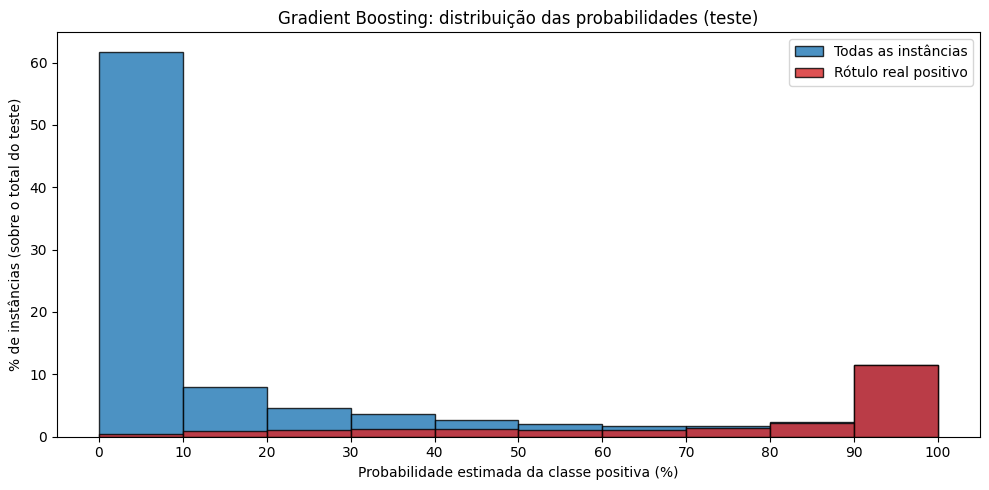

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def histograma_probabilidades(prob, y_real, largura=10, cortes=None, titulo=""):
    p = np.asarray(prob) * 100          # probabilidade em %
    y = np.asarray(y_real)

    # bordas dos intervalos (a última sempre termina em 100)
    bordas = np.arange(0, 100 + 1e-9, largura)
    if bordas[-1] < 100:
        bordas = np.append(bordas, 100)

    total = len(p)                       # MESMO denominador para azul e vermelho
    cont_todas, _ = np.histogram(p, bins=bordas)        # azul: todas as instâncias
    cont_pos, _   = np.histogram(p[y == 1], bins=bordas) # vermelho: só rótulo real positivo
    perc_todas = cont_todas / total * 100
    perc_pos   = cont_pos   / total * 100

    assert cont_todas.sum() == total     # cada instância está em exatamente 1 intervalo

    fig, ax = plt.subplots(figsize=(10, 5))
    larguras = np.diff(bordas)
    ax.bar(bordas[:-1], perc_todas, width=larguras, align="edge",
           color="tab:blue", edgecolor="black", alpha=0.8,
           label="Todas as instâncias")
    ax.bar(bordas[:-1], perc_pos, width=larguras, align="edge",
           color="tab:red", edgecolor="black", alpha=0.8,
           label="Rótulo real positivo")

    if cortes is not None:               # linhas dos cortes t1 e t2 (item ix)
        t1, t2 = cortes
        ax.axvline(t1 * 100, color="black", linestyle="--", label=f"t1 = {t1*100:.0f}%")
        ax.axvline(t2 * 100, color="black", linestyle=":",  label=f"t2 = {t2*100:.0f}%")

    ax.set_xticks(bordas)
    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("% de instâncias (sobre o total do teste)")
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()

histograma_probabilidades(prob_classe1_gb, y_test, largura=10,
                          titulo="Gradient Boosting: distribuição das probabilidades (teste)")

In [16]:
from sklearn.model_selection import cross_val_predict

# probabilidades de VALIDAÇÃO (o modelo prevê dados que não viu), só com x_dev
p_val = cross_val_predict(modelo_gb, x_dev, y_dev, cv=validacao_cruzada,
                          method="predict_proba")[:, 1]
y_val = np.array(y_dev)

grade = np.round(np.arange(0.01, 1.00, 0.01), 2)

def escolher_cortes(tol_neg, tol_pos):
    """
    t1: o MAIOR corte em que, entre os classificados como negativos automáticos,
        a proporção de positivos reais é <= tol_neg.
    t2: o MENOR corte em que, entre os classificados como positivos automáticos,
        a proporção de negativos reais é <= tol_pos.
    """
    t1 = None
    for t in grade:
        m = p_val < t
        if m.sum() > 0 and y_val[m].mean() <= tol_neg:
            t1 = t
    t2 = None
    for t in grade[::-1]:
        m = p_val >= t
        if m.sum() > 0 and (1 - y_val[m].mean()) <= tol_pos:
            t2 = t
    return t1, t2

# tabela para você justificar a escolha: tolerâncias diferentes dão cortes diferentes
print("Tolerância de erro | t1 | t2 | %neg.auto | %manual | %pos.auto (validação)")
for tol in [0.02, 0.05, 0.10]:
    a, b = escolher_cortes(tol, tol)
    if a is not None and b is not None and a < b:
        neg = (p_val < a).mean() * 100
        pos = (p_val >= b).mean() * 100
        print(f"{tol*100:>4.0f}%              | {a:.2f} | {b:.2f} | {neg:6.1f}%  | {100-neg-pos:6.1f}% | {pos:6.1f}%")
    else:
        print(f"{tol*100:>4.0f}%              | tolerância muito apertada: não há faixas válidas")

# ESCOLHA FINAL (mude as tolerâncias conforme o seu domínio)
TOL_NEG = 0.05
TOL_POS = 0.05
T1, T2 = escolher_cortes(TOL_NEG, TOL_POS)
print(f"\nCortes escolhidos na validação: t1 = {T1:.2f} ({T1*100:.0f}%) | t2 = {T2:.2f} ({T2*100:.0f}%)")

Tolerância de erro | t1 | t2 | %neg.auto | %manual | %pos.auto (validação)
   2%              | 0.18 | 0.81 |   68.3%  |   17.9% |   13.8%
   5%              | 0.40 | 0.69 |   78.1%  |    5.9% |   16.0%
  10%              | tolerância muito apertada: não há faixas válidas

Cortes escolhidos na validação: t1 = 0.40 (40%) | t2 = 0.69 (69%)


In [17]:
import pandas as pd

p_teste = prob_classe1_gb
y_teste = np.array(y_test)
total = len(y_teste)

faixa = np.where(p_teste < T1, "1. Negativa automática",
         np.where(p_teste < T2, "2. Análise manual", "3. Positiva automática"))

linhas = []
for nome_faixa in ["1. Negativa automática", "2. Análise manual", "3. Positiva automática"]:
    m = faixa == nome_faixa
    n = m.sum()
    pos = int(y_teste[m].sum())
    neg = int(n - pos)
    linhas.append({
        "Faixa": nome_faixa,
        "Instâncias": n,
        "% da população (de 9000)": round(n / total * 100, 2),
        "Positivos reais": pos,
        "Negativos reais": neg,
        "% positivos dentro da faixa": round(pos / n * 100, 2) if n else 0,
        "% negativos dentro da faixa": round(neg / n * 100, 2) if n else 0,
    })
tabela_faixas = pd.DataFrame(linhas).set_index("Faixa")
display(tabela_faixas)

# erros automáticos, com denominador explícito
tot_pos = int(y_teste.sum())
tot_neg = total - tot_pos
m_neg = faixa == "1. Negativa automática"
m_pos = faixa == "3. Positiva automática"
fn_auto = int(y_teste[m_neg].sum())          # positivos jogados em "negativa automática"
fp_auto = int((1 - y_teste[m_pos]).sum())    # negativos jogados em "positiva automática"

print(f"Positivos classificados automaticamente como negativos: {fn_auto}")
print(f"   = {fn_auto/tot_pos*100:.2f}% dos {tot_pos} positivos reais do teste")
print(f"   = {fn_auto/m_neg.sum()*100:.2f}% das {m_neg.sum()} instâncias classificadas como negativas automáticas")
print(f"Negativos classificados automaticamente como positivos: {fp_auto}")
print(f"   = {fp_auto/tot_neg*100:.2f}% dos {tot_neg} negativos reais do teste")
print(f"   = {fp_auto/m_pos.sum()*100:.2f}% das {m_pos.sum()} instâncias classificadas como positivas automáticas")
print(f"Cobertura automática: {(m_neg.sum()+m_pos.sum())/total*100:.2f}% | Análise manual: {(faixa=='2. Análise manual').mean()*100:.2f}%")

,Instâncias,% da população (de 9000),Positivos reais,Negativos reais,% positivos dentro da faixa,% negativos dentro da faixa
Faixa,,,,,,
1. Negativa automática,7018,77.98,335,6683,4.77,95.23
2. Análise manual,555,6.17,298,257,53.69,46.31
3. Positiva automática,1427,15.86,1367,60,95.80,4.20


Positivos classificados automaticamente como negativos: 335
   = 16.75% dos 2000 positivos reais do teste
   = 4.77% das 7018 instâncias classificadas como negativas automáticas
Negativos classificados automaticamente como positivos: 60
   = 0.86% dos 7000 negativos reais do teste
   = 4.20% das 1427 instâncias classificadas como positivas automáticas
Cobertura automática: 93.83% | Análise manual: 6.17%


/home/disponivel/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


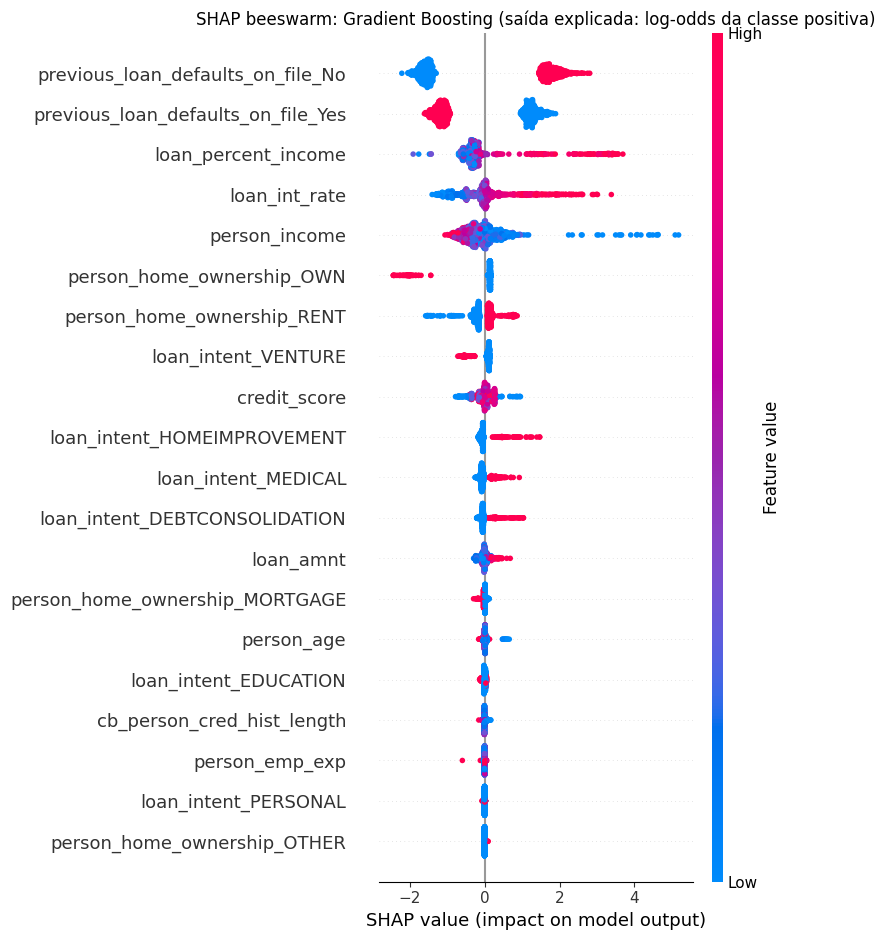

In [19]:
import shap

pre = modelo_gb.named_steps["preprocessamento"]
gb  = modelo_gb.named_steps["modelo"]
nomes = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]

amostra = x_test.sample(1000, random_state=42)     # 1000 instâncias do conjunto de TESTE
X_amostra = pre.transform(amostra)
if hasattr(X_amostra, "toarray"):
    X_amostra = X_amostra.toarray()
X_amostra = pd.DataFrame(X_amostra, columns=nomes)

explicador = shap.TreeExplainer(gb)
shap_values = explicador.shap_values(X_amostra)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_amostra, show=False)
plt.title("SHAP beeswarm: Gradient Boosting (saída explicada: log-odds da classe positiva)")
plt.tight_layout()
plt.show()